<a href="https://colab.research.google.com/github/dimkpapadopoulos/machine-learning-projects/blob/main/Lung_Cancer_Detection_with_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook, we examine a classic use-case of Neural Networks. Given a small image dataset of lung tissue samples, a deep neural network, with 3 hidden convolutional layers and one dense is employed to classify them under 3 distinct classes:

*   Normal (lung_n)
*   Adenocarcinoma (lung_aca)
*   Squamous cell carcinoma (lung_scc)

In [ ]:
# extract dataset from zip file
!unzip /content/lung_subset_small-20260515T162105Z-3-001.zip -d /content/

In [ ]:
# library imports
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn import metrics

import tensorflow as tf
from tensorflow import keras
from keras import layers

import warnings
warnings.filterwarnings('ignore')

Here we can see 3 examples from each class.

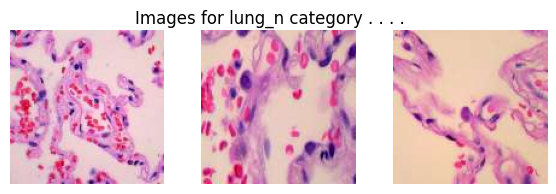

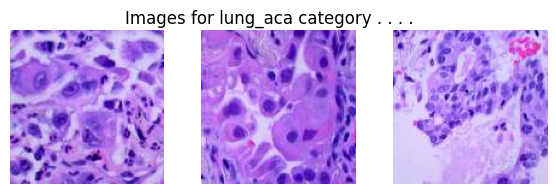

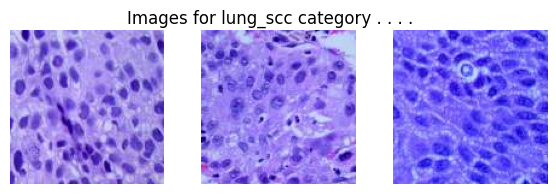

In [ ]:
path = 'lung_subset_small'

classes = ['lung_n', 'lung_aca', 'lung_scc']

for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(7, 2))
    fig.suptitle(f'Images for {cat} category . . . .')

    for i in range(3):
        k = np.random.randint(0, len(images))
        img = np.array(Image.open(f'{path}/{cat}/{images[k]}'))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

We load the dataset into a Tensorflow dataset with the given train/validation split and apply resizing, batching and normalization of pixel values to the 0-1 range.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10

datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1680 images belonging to 3 classes.
Found 720 images belonging to 3 classes.


We declare the Neural Network architecture to have 3 convolutional layers of 16, 32 and 64 filters respectively. After each one, Max Pooling is applied to gradually reduce dimensionality. At the end, there is a dense layer of 256 neurons and the output of 3, matching our dataset's 3 classes. Activation for the hidden layers is ReLU and for the output layer is Softmax (probability of each class).

In [ ]:
model = keras.models.Sequential([
    layers.Conv2D(16, (5, 5), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,220,707 (16.10 MB)

 Trainable params: 4,220,195 (16.10 MB)

 Non-trainable params: 512 (2.00 KB)

The resulting Neural Network has 4.2 million parameters, a decently small size. We declare a couple of callbacks to stop training early in case of reaching high accuracy in the validation set and one to reduce our optimizer's learning rate in case validation loss reaches a plateau.

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.95:
            print("Stopping early")
            self.model.stop_training = True

es = EarlyStopping(patience=5, monitor='val_accuracy', restore_best_weights=True)

lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5)

model.compile(
    optimizer=keras.optimizers.Adam(2e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

The model is trained for 10 epochs at most, or until it reaches 95% accuracy, or if the validation accuracy fails to improve for 5 epochs. These are all arbitrarily declared.

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[es, lr, myCallback()]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.7149 - loss: 0.5812 - val_accuracy: 0.7833 - val_loss: 0.7233 - learning_rate: 2.0000e-04
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.8506 - loss: 0.3502 - val_accuracy: 0.8806 - val_loss: 0.6685 - learning_rate: 2.0000e-04
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9071 - loss: 0.2522 - val_accuracy: 0.8833 - val_loss: 0.5823 - learning_rate: 2.0000e-04
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9292 - loss: 0.1997 - val_accuracy: 0.8889 - val_loss: 0.4913 - learning_rate: 2.0000e-04
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9583 - loss: 0.1447 - val_accuracy: 0.8569 - val_loss: 0.4129 - learning_rate: 2.0000e-04
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9732 - loss: 0.0992 - val_accuracy: 0.8792 - val_loss: 0.4317 - learning_rate: 2.0000e-04
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.989

Below we can see the progress of accuracy across the two subsets, with our validation reaching over 90% accuracy.

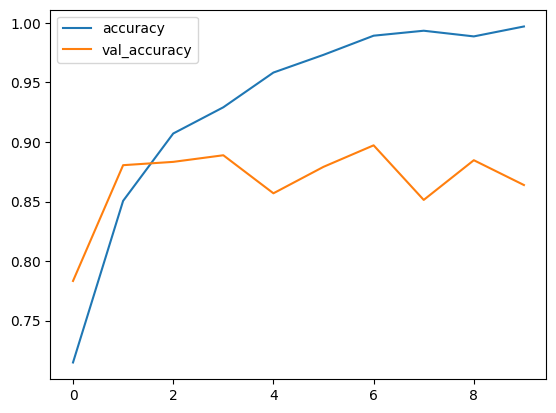

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

In [ ]:
Y_pred = model.predict(val_data)
Y_pred_labels = np.argmax(Y_pred, axis=1)
Y_true = val_data.classes
from sklearn import metrics

print(metrics.classification_report(
    Y_true,
    Y_pred_labels,
    target_names=classes
))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
              precision    recall  f1-score   support

      lung_n       0.33      0.36      0.34       240
    lung_aca       0.34      0.33      0.34       240
    lung_scc       0.35      0.33      0.34       240

    accuracy                           0.34       720
   macro avg       0.34      0.34      0.34       720
weighted avg       0.34      0.34      0.34       720

